## Mount the Drive so Colab can access your files

In [74]:
from google.colab import drive  # Gives Colab access to Google Drive.
import os  # Provides tools for checking folders and changing directories.

# Colab mounts Google Drive at this fixed location.
drive_path = '/content/drive'
my_drive_path = os.path.join(drive_path, 'My Drive')

# Check whether the Drive mount is already available.
try:
    drive_is_mounted = os.path.isdir(my_drive_path)
except OSError:
    drive_is_mounted = False

# Mount Google Drive only when needed.
if not drive_is_mounted:
    drive.mount(drive_path, force_remount=True)
else:
    print('Google Drive is already mounted.')

my_folder_path = 'Teaching/Distributed Energy Resources/Notebooks/HW4 - Solar'
target_folder = os.path.join(my_drive_path, my_folder_path)

os.chdir(target_folder)
print('Working directory:', os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/My Drive/Teaching/Distributed Energy Resources/Notebooks/HW4 - Solar


# Solar

This notebook simulates residential electricity demand and solar photovoltaic power output. It computes the annual cost savings from solar under one-to-one net metering and net metering with a reduced buyback price. In order to do so, first the solar angles and the surface irradiance on a tilted panel are calculated. Then, the solar power output is computed based on panel characteristics. Finally, the electricity demand is simulated and the cost savings are calculated.

## Solar Angles

This first part will compute the solar angles for a given location and time of year. As noted in the lecture slides, the solar angle i.e., the sun's elevation ($\theta$) and azimumth ($\alpha$) angles can be calculated using the latitude, declination angle, and hour angle.

$$
\alpha = 90^\circ - \text{acos}[ \sin(\phi_0) \sin(\delta) + \cos(\phi_0) \cos(\delta) \cos(\lambda) ] \tag{1} \\
$$
$$
\theta = \text{atan2}[ \cos(\delta) \sin(\lambda), \sin(\phi_0) \cos(\delta) \cos(\lambda) - \cos(\phi_0) \sin(\delta) ] \tag{2}\\

$$

where $\phi_0$ is the observer's latitude, $\delta$ is the declination angle, and $\lambda$ is the hour angle. The delicnation angle can be calculated as follows:

$$
\gamma = 360^\circ / 365 \times (n - 81) \tag{3}
$$

$$
\delta = 23.45^\circ \sin \left( \gamma \right) \tag{4} \\
$$

where $n$ is the day of the year (1 to 365) at GMT. In order to calculate the hour angle $\lambda$, we first need to compute the solar time. The local solar time is calculated by adding a correction factor ($\tau$) to GMT time, where
$$
\tau \approx (0.165 \text{ h}) \sin(2\gamma) - (0.126 \text{ h}) \cos(\gamma) - (0.025 \text{ h}) \sin(\gamma)  \tag{5} \\
$$

So the local solar time is given by the GMT time plus $\tau$. The hour angle is then given by:

$$
\lambda = \lambda_0 + (15 \text{ $^\circ$/h}) (t_\text{gm} + \tau - 12 \text{ h} ) \tag{6} \\
$$

Therefore, using $\lambda$, $\delta$, and $\phi_0$ the solar azimuth and elevation angles can be calculated using equations (1) and (2).

In [75]:
import numpy as np
import pandas as pd

def solar_angles(lat, long, t, offset_gmt):
    """
     solarAngles computes the sun's elevation and azimuth angles, as seen by
     an observer at the input location.

     Input arguments must be scalars or columns.

     Inputs:
       lat, the observer's latitude in degrees
       long, the observer's longitude in degrees
       t, the local datetime or array of datetimes
       offset_gmt, the time difference between local and GMT
           (for example, offset_gmt = -5 for US Eastern Time)

     Outputs:
       el, the sun's elevation angle in degrees
           convention: 0 at sunrise/sunset
       az, the sun's azimuth angle in degrees
           convention: 0 south, 90 west, +/-180 north, -90 east
 """
    # GMT datetime
    t_gmt = t - pd.to_timedelta(offset_gmt, unit='h')

    # intermediate angle, degrees
    gam = 360 / 365 * (t_gmt.dayofyear - 81)

    # declination, degrees
    dec = 23.45 * np.sin(np.radians(gam))

    # 'equation of time' adjustment, hours
    tau = 0.1645 * np.sin(np.radians(2 * gam)) - 0.1255 * np.cos(np.radians(gam)) - 0.025 * np.sin(np.radians(gam))

    # hour angle, degrees
    hours_since_midnight = t_gmt.hour + t_gmt.minute / 60 + t_gmt.second / 3600
    lam = long + 15 * (hours_since_midnight + tau - 12)

    # elevation, degrees
    el = 90 - np.degrees(np.arccos(np.sin(np.radians(lat)) * np.sin(np.radians(dec)) +
                                   np.cos(np.radians(lat)) * np.cos(np.radians(dec)) * np.cos(np.radians(lam))))

    # azimuth, degrees
    az = np.degrees(np.arctan2(np.cos(np.radians(dec)) * np.sin(np.radians(lam)),
                               np.sin(np.radians(lat)) * np.cos(np.radians(dec)) * np.cos(np.radians(lam)) -
                               np.cos(np.radians(lat)) * np.sin(np.radians(dec))))

    return el, az

## Surface Irradiance on a Tilted Panel

Next, we can compute the surface irradiance on a tilted solar panel. To do so first the weather data at the given location must be used to obtain the beam normal irradiance and the diffuse horizontal irradiance. Then, the surface irradiance on a tilted panel can be calculated as follows:

$$
S_\text{b} = \begin{cases}  
0 \text{ if } \alpha < 0^\circ \text{ or } 90^\circ < | \theta - \theta_0 | < 270^\circ \tag{7} \\
S_\text{b}^\perp [ \cos(\alpha) \sin(\beta) \cos(\theta - \theta_0) + \sin(\alpha) \cos(\beta) ] \text{ else} \\
\end{cases} \\
$$
$$
S_\text{d} \approx S_\text{d}^- \tag{8} \\
$$
$$
S_\text{tot} = S_\text{b} + S_\text{d} \tag{9} \\
$$

where $S_\text{b}^\perp$ is the beam normal irradiance, $S_\text{d}^-$ is the diffuse horizontal irradiance, $\beta$ is the tilt angle of the panel, and $\theta_0$ is the azimuth angle of the panel. The total surface irradiance on the tilted panel is then given by the sum of the beam and diffuse components.

In [76]:
def surface_irradiance(az, el, az0, tilt, beam_normal, diffuse_horizontal):
    """
    surface_irradiance calculates the solar irradiance on a surface, meaning
    the power per unit area from sunlight.

    Input:
        az, a K x 1 vector of solar azimuth angles, in degrees
        el, a K x 1 vector of solar elevation angles, in degrees
        az0, a scalar surface azimuth angle, in degrees
        tilt, a scalar surface tilt angle, in degrees
        beam_normal, a K x 1 vector of beam irradiances on a surface normal to
            the sun, in kW/m^2
        diffuse_horizontal, a K x 1 vector of diffuse irradiances on a
            horizontal surface, in kW/m^2

    Output:
        Stot, the total irradiance on the surface, in kW/m^2
        Sb, the beam irradiance on the surface, in kW/m^2
        Sd, the diffuse irradiance on the surface, in kW/m^2
    """
    # beam irradiance, kW/m^2
    az = np.asarray(az)
    el = np.asarray(el)
    beam_normal = np.asarray(beam_normal)
    diffuse_horizontal = np.asarray(diffuse_horizontal)

    Sb = beam_normal * (np.sin(np.radians(tilt)) * np.cos(np.radians(el)) *
                        np.cos(np.radians(az - az0)) + np.cos(np.radians(tilt)) * np.sin(np.radians(el)))

    Sb = np.array(Sb)

    # zero if sun is down or behind surface
    mask = (el < 0) | ((np.abs(az - az0) > 90) & (np.abs(az - az0) < 270))
    Sb[mask] = 0

    # diffuse irradiance, kW/m^2
    Sd = np.array(diffuse_horizontal)

    # total irradiance, kW/m^2
    Stot = Sb + Sd

    return Stot, Sb, Sd

## Weather Import
To compute the solar power output, we need to import the weather data for the given location. This data should include the beam normal irradiance and the diffuse horizontal irradiance for each hour of the year. The data can be extracted from the weather file included in this directory.

In [77]:
import pandas as pd

def import_weather(file_name, t_span):
    """
    importWeather imports and processes weather data from a CSV file
    generated by OikoLab.

    Input:
      fileName, the name of the OikoLab CSV weather file.
      t, the datetime span.

    Output:
      temperature, the outdoor temperature in C
      totalHorizontal, the total solar shortwave irradiance on a horizontal surface in kW/m^2
      beamNormal, the beam solar shortwave irradiance on a normal surface in kW/m^2
      diffuseHorizontal, the diffuse solar shortwave irradiance on a horizontal surface in kW/m^2
      offsetGMT, (local time) - (Greenwich mean time) in hours
    """

    # import raw data
    weather_data = pd.read_csv(file_name)

    # extract data and convert units
    weather_data['timestamp'] = pd.to_datetime(
        weather_data.iloc[:, 0], format='%m/%d/%y %H:%M', errors='coerce'
    )

    # Fix year only if it's before 2000 to avoid overflow issues
    mask = weather_data['timestamp'].dt.year < 2000
    weather_data.loc[mask, 'timestamp'] = weather_data.loc[mask, 'timestamp'].apply(
        lambda x: x.replace(year=x.year + 2000)
    )

    # convert UTC to local time
    offsetGMT = weather_data.iloc[:, 4].values
    weather_data['timestamp'] += pd.to_timedelta(offsetGMT, unit='h')

    # set timestamp as index
    weather_data.set_index('timestamp', inplace=True)

    # extract data and convert units
    temperature = weather_data.iloc[:, 5].values  # outdoor air temperature, C
    total_horizontal = weather_data.iloc[:, 6].values / 1000  # total horizontal shortwave irradiance, kW/m^2
    beam_normal = weather_data.iloc[:, 7].values / 1000  # beam normal shortwave irradiance, kW/m^2
    diffuse_horizontal = weather_data.iloc[:, 8].values / 1000  # diffuse horizontal shortwave irradiance, kW/m^2

    # fill any missing data
    weather_data.interpolate(method='linear', inplace=True)

    # pack the data into a timetable object
    weather_data = weather_data.reindex(t_span).interpolate(method='linear')

    # retime to the desired time steps
    temperature = weather_data.iloc[:, 5].values
    total_horizontal = weather_data.iloc[:, 6].values / 1000
    beam_normal = weather_data.iloc[:, 7].values / 1000
    diffuse_horizontal = weather_data.iloc[:, 8].values / 1000
    offsetGMT = weather_data.iloc[:, 4].values

    # fill any missing data again
    temperature = pd.Series(temperature).interpolate(method='linear').values
    total_horizontal = pd.Series(total_horizontal).interpolate(method='linear').values
    beam_normal = pd.Series(beam_normal).interpolate(method='linear').values
    diffuse_horizontal = pd.Series(diffuse_horizontal).interpolate(method='linear').values
    offsetGMT = pd.Series(offsetGMT).interpolate(method='linear').values

    return temperature, total_horizontal, beam_normal, diffuse_horizontal, offsetGMT


## Building Power Consumption

To evaluate the cost savings from solar, we need to simulate the building's electricity demand. In the given directory, a csv file that contains electricity demand profiles of 390 homes in New York City. These have been averaged to create 26 gorups of 15 apartments each. This will be imported in the following function:

In [78]:
import pandas as pd

def import_electricity(file_name, t_span):
    """
    importElectricity imports and processes electrical load data from the
    MFRED (Multi Family Residential Electricity Demand) csv file. This
    dataset contains electricity demand profiles for 390 multifamily
    apartments in New York City, anonymized by averaging the 390 into 26
    groups of 15 apartments each.

    Input:
      fileName, the name of the MFRED file.
      t, the datetime span.

    Output:
      P, a length(t) x 26 matrix of electricity demand data
    """

    # import raw data
    raw_data = pd.read_csv(file_name)

    # extract power data
    raw_data['timestamp'] = pd.to_datetime(
        raw_data.iloc[:, 0],
        format='%m/%d/%y %H:%M',
        errors='coerce'
    )

    # fix year from e.g. 20 to 2020
    if raw_data['timestamp'].dt.year.iloc[0] < 2000:
        raw_data.loc[:, 'timestamp'] = raw_data['timestamp'].apply(lambda x: x.replace(year=x.year + 2000))

    # convert UTC to eastern
    raw_data['timestamp'] -= pd.Timedelta(hours=5)

    # set timestamp as index
    raw_data.set_index('timestamp', inplace=True)

    # indices of kW columns
    power_columns = raw_data.columns[4::3]
    individual_power = raw_data[power_columns].copy()  # individual power profiles

    # fill any missing data
    individual_power.interpolate(method='linear', inplace=True)

    # retime to the desired time span
    individual_power = individual_power.reindex(t_span).interpolate(method='linear')

    # fill any missing data again
    individual_power.interpolate(method='linear', inplace=True)

    # extract power data from dataframe into matrix
    P = individual_power.to_numpy()

    return P


Although the electricity demand profiles is imported we shall first scale them to $5W/m^2$ to estimate the average value of plug power per apartment. In addition, the heating and cooling loads of the building will be estimate using 1R1C building model operating with a heat pump. The COP of the heat pump is a linear function of the outdoor air temperature and depends also on the season. The COP is given by the following equations:

$$
\text{COP} = \begin{cases}
\text{COP}_\text{winter} = max(1, 0.0449 \times T_\text{out} + 2.57) \text{ if } t<15^{th}April \text{ or } t>15^{th}October \tag{10} \\
\text{COP}_\text{summer} = 0.197 \times T_\text{out} - 10.3 \text{ else} \\
\end{cases}
$$

where $T_\text{out}$ is the outdoor air temperature in degrees Celsius and $t$ is the time. The total exogenous thermal power is given by the summation of plug power, the soalr heat gain through the windows and the thermal power from everything else. The thermal power from everything else is estimated as a random variable with a mean of $0.5 W/m^2$ and a standard deviation of $0.25 W/m^2$. The solar heat gain through the windows is given by the following equation:

$$
Q^{win}_{solar} = 0.19 \sqrt{N A_f} c S_{tot}^- \tag{11}
$$

where $N$ is the number of floors, $A_f$ is the floor area, $c$ is the solar heat gain coefficient (0.8 in winter and 0.5 in summer), and $S_{tot}^-$ is the total horizontal surface irradiance. The total exogenous thermal power is then given by:
$$
Q_e = P_{plug} + Q^{win}_{solar} + Q_{other} \tag{12}
$$
where $P_{plug}$ is the plug power, $Q^{win}_{solar}$ is the solar heat gain through the windows, and $Q_{other}$ is the thermal power from everything else. The 1R1C model can be represented in its discrete time form as follows:
$$
T(k+1) = aT(k) + (1-a)R(Q_c+Q_e+T_{out}/R) \tag{13}
$$
where $T(k)$ is the indoor temperature at time step $k$, $a = e^{-\Delta t/(RC)}$ is the thermal inertia factor, $R$ is the thermal resistance, $C$ is the thermal capacitance, $Q_c$ is the thermal power from the heat pump, and $Q_e$ is the exogenous thermal power. The setpoint temperature is given by $T_{sp}$. The control strategy for the heat pump is to track the setpoint temperature exactly, but the thermal power from the heat pump cannot exceed its maximum thermal power. Therefore, the required thermal power from the heat pump at every point in time can be obtained by running the 1R1C simulation under this control strategy.

In order to find the thermal power at every point in time we need to find the maximum thermal power of the heat pump. This implies that the heat pump needs to be sized. In order to do so consider the design condition when the outdoor temperature is in the 1st percentile of the outdoor temperature distribution and the indoor temperature is at the setpoint temperature. The maximum electric power of the heat pump is then given by:
$$
P_{max} = 1.2 \times (\frac{1}{COP})(\frac{T_{sp} - T_{out}}{R - Q_e})\tag{14}
$$
where $Q_e$ is the exogenous thermal power and $\text{COP}$ is the coefficient of performance of the heat pump at the design condition, $T_{sp}$ is the setpoint temperature, $T_{out}$ is the outdoor temperature, and $R$ is the thermal resistance. This equation is derived by using the 1R1C model to find the required thermal power to maintain the indoor temperature at the setpoint temperature under the design condition. The maximum electric power of the heat pump is then given by the required thermal power divided by the COP, multiplied by a safety factor of 1.2 to account for any uncertainties in the estimation.

The maximum HVAC thermal power is just the COP at that point in time mulitplied by the maximum electric power of the heat pump. Now the required thermal power of the heat pump at every point in time can be obtained by running the 1R1C simulation under the control strategy that the thermal load tracks setpoint exactly but is clipped within the maximum thermal power of the heat pump as calculated previously. The amount of thermal power required to meet the setpoint temperature at the next time step can be calculated using the 1R1C model. Subsequently this value must be clipped within the maximum thermal power of the heat pump at that point in time. Once the actual thermal power is obtained, the electric power can be calculated by dividing the thermal power by the COP at that point in time. The total electric power consumption of the building is then given by the summation of the electric power from the heat pump and the plug power.

$$
Q_{c} = \max(Q_{c}^{\min}, \min(Q_{c}^{\max}, \frac{T_{sp} - aT(k)}{(1-a)R} - (Q_e+T_{out}/R))) \tag{15}
$$

Therfore, the electric power consumption of the building is given by:
$$
P = P_{plug} + \frac{Q_c}{COP} \tag{16}
$$

In [79]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def generate_electricity_demand(t_span, electricity_file, Af, N, theta, total_horizontal, to_plot):
    # generateElectricityDemand generates an electricity demand profile for a
    # building, including heating/cooling equipment and everything else, over a
    # given time span.

    # Input:
    #   t_span, the K x 1 time span as a datetime object
    #   electricity_file, a string containing the electricity data file name
    #   Af, the floor area, m^2
    #   N, the number of stories
    #   theta, the K x 1 outdoor temperature, C
    #   total_horizontal, the K x 1 total horizontal solar irradiance, kW/m^2
    #   to_plot, an indicator of whether to plot simulation data and results

    # Output:
    #   p, a K x 1 vector of total electricity demand, kW

    # timing
    K = len(t_span)  # number of time steps
    dt = (t_span[1] - t_span[0]).total_seconds() / 3600  # time step, h

    # electricity data import
    t_elec = t_span.copy()
    t_elec = t_elec.map(lambda t: t.replace(year=2019))  # electricity time span (data are from 2019)
    plug_powers = import_electricity(electricity_file, t_elec)  # 'everything else' electricity data import
    print("Scaling factor: ", (0.005 * Af / np.mean(plug_powers, axis=0)))
    print("Ratio of plug  power to mean: ", plug_powers[:, -1] / np.mean(plug_powers[:, -1]))
    plug_powers = plug_powers * (0.005 * Af / np.mean(plug_powers, axis=0)) # plug powers rescaled by floor area to 5 W/m^2, kW


    # 1R1C building model parameters
    C = 0.0125 * Af  # air thermal capacitance, kWh/C
    R = 1 / (0.016 * np.sqrt(N * Af))  # indoor-outdoor thermal resistance, C/kW
    a = np.exp(-dt / (R * C))  # discrete-time dynamics parameter

    # indoor temperature setpoint
    is_winter = (t_span <= pd.Timestamp("2022-04-15")) | (t_span >= pd.Timestamp("2022-10-15"))  # indicator of heating season
    is_summer = (t_span >= pd.Timestamp("2022-05-01")) & (t_span <= pd.Timestamp("2022-09-30"))  # indicator of cooling season
    T_set = np.full(K, 21)  # indoor temperature setpoint, C
    T_set[is_summer] = 25  # cooling temperature setpoint, C

    # heat pump coefficient of performance
    eta = np.ones(K)  # heat pump coefficient of performance (initialized at 1 to avoid dividing qc by 0 when calculating p)
    eta[is_winter] = np.maximum(1, 0.0449 * theta[is_winter] + 2.57)  # heating COP
    eta[is_summer] = 0.197 * theta[is_summer] - 10.3  # cooling COP

    # coefficient of performance plot
    if to_plot:
        plt.figure(1, figsize=(12, 6))
        plots = [
            (theta, 'Outdoor\ntemperature (°C)', [-20, 0, 20, 40]),
            (eta, 'Heat pump coefficient\nof performance',
             np.arange(np.floor(min(eta)), np.ceil(max(eta)) + 1, step=5))
        ]

        for i, (y_data, ylabel, yticks) in enumerate(plots, 1):
            ax = plt.subplot(2, 1, i)
            plt.plot(t_span, y_data, 'k', linewidth=2)
            ax.set(ylabel=ylabel)#), yticks=yticks)
            # ax.tick_params(axis='both', labelsize=16)
            ax.xaxis.set_major_locator(mdates.MonthLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
            ax.grid(True)
            if i == 2:
                ax.text(t_span[-1], min(eta) - 4, '2022', fontsize=16, ha='right', va='center', fontname='serif')


    # exogenous thermal power
    i_power = plug_powers.shape[1] - 3 # index of power profile
    c = np.full(K, 0.8)  # solar heat gain coefficient
    c[is_summer] = 0.5  # lower SHGC in summer to emulate shading

    # qe = (plug_powers[:, i_power] + 0.19 * np.sqrt(N * Af) * c * total_horizontal
    #       + 0.5 + (0.25 / 3) * np.random.randn(K))  # from everything else

    qe = (np.mean(plug_powers,axis=1) + 0.19 * np.sqrt(N * Af) * c * total_horizontal
          + 0.5 + (0.25 / 3) * np.random.randn(K))  # from everything else
    # exogenous thermal power plot
    if to_plot:
        plt.figure(2, figsize=(20, 6))
        plots = [
            (np.mean(plug_powers,axis=1), 'Plug\npower (kW)'),
            (qe, 'Exogenous thermal\npower (kW)')
        ]

        for i, (y_data, ylabel) in enumerate(plots, 1):
            ax = plt.subplot(2, 1, i)
            plt.plot(t_span, y_data, 'k', linewidth=2)
            ax.set(ylabel=ylabel)
            ax.tick_params(axis='both', labelsize=16)
            ax.xaxis.set_major_locator(mdates.MonthLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
            ax.grid(True)
            if i == 2:
                ax.text(t_span[-1], min(qe) - 3, '2022', fontsize=16, ha='right', va='center', fontname='serif')


    # heat pump sizing
    kd = np.argmin(np.abs(theta - np.quantile(theta, 0.01)))  # time index of design condition
    p_max = 1.2 * ((T_set[kd] - theta[kd]) / R - qe[kd]) / eta[kd]  # heat pump electric power capacity, kW
    qc_max = np.zeros(K)  # maximum heat pump thermal power, kW
    qc_max[is_winter] = p_max * eta[is_winter]  # nonzero heating capacity in winter
    qc_min = np.zeros(K)  # minimum heat pump thermal power, kW
    qc_min[is_summer] = p_max * eta[is_summer]  # nonzero cooling capacity in summer

    # data storage
    T = np.zeros(K + 1)  # indoor temperature, C
    T[0] = T_set[0]  # initial state, C
    qc = np.zeros(K)  # heat pump thermal power, kW

    # thermal simulation
    for k in range(K):
        # thermal load to exactly track setpoint
        lk = ((T_set[min(k + 1, K - 1)] - a * T[k]) / (1 - a) - theta[k]) / R - qe[k]  # thermal load, kW

        # heat pump thermal power
        qc[k] = np.clip(lk, qc_min[k], qc_max[k])  # heat pump thermal power, kW
        if not (is_winter[k] or is_summer[k]):  # if it's not heating or cooling season
            qc[k] = 0  # turn heat pump off

        # temperature update
        T[k + 1] = a * T[k] + (1 - a) * (theta[k] + R * (qc[k] + qe[k]))  # C

    # electric power simulation
    p = np.mean(plug_powers,axis=1) + qc / eta  # total building electrical load, kW

    # building simulation results plot
    if to_plot:
        plt.figure(3, figsize=(12, 6))
        plots = [
            (T[:-1], 'Indoor\ntemperature\n(°C)', None),
            (qc, 'Heat pump\nthermal power\n(kW)', None),
            (p, 'Total electrical\npower (kW)', [0, 5, 10])
        ]

        for i, (y_data, ylabel, yticks) in enumerate(plots, 1):
            ax = plt.subplot(3, 1, i)
            plt.plot(t_span, y_data, 'k', linewidth=2)
            ax.set_ylabel(ylabel, labelpad=10, loc='center', fontsize=12)
            ax.tick_params(axis='both', labelsize=12)
            ax.xaxis.set_major_locator(mdates.MonthLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
            ax.grid(True)
            if yticks is not None:
                ax.set_yticks(yticks)
            if i == 3:
                ax.text(t_span[-1], min(p) - 3, '2022', fontsize=12, ha='right', va='center')

        plt.show()

        plt.figure(4, figsize=(20, 5))
        ax = plt.subplot(1,1,1)
        plt.plot(t_span, np.mean(plug_powers,axis=1), "b", linewidth=2, label='Plug power')
        plt.plot(t_span, p, "k", linewidth=2, label='Total power including HVAC Power')
        ax.set_ylabel('Total Electric Power (kW)', labelpad=10, loc='center', fontsize=12)
        ax.tick_params(axis='both', labelsize=12)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.grid(True)
        ax.set_yticks([0,5,10])
        # if i == 3:
        #     ax.text(t_span[-1], min(p) - 3, '2022', fontsize=12, ha='right', va='center')
        ax.legend(loc='upper left', fontsize=12)
        plt.show()
    return p

## Analysis

Let us now analyze the cost savings from solar under one-to-one net metering and net metering with a reduced buyback price. First the weather data is imported for an year of data at 15 minute intervals.


In [80]:
import matplotlib.ticker as mticker  # Import ticker for formatting
# ==============================================================================
# graphics settings
# ==============================================================================


plt.rc('font', size=12)
plt.rc('axes', titlesize=12, labelsize=12)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=12)
plt.rc('figure', titlesize=15)
plt.rc('lines', linewidth=3)

# ==============================================================================
# input data
# ==============================================================================

# timing
dt = 0.25  # time step, h
t_span = pd.date_range(start='2022-01-01', end='2022-12-31 23:00:00', freq=f'{int(dt*60)}min') # time span as datetime
K = len(t_span)  # number of time steps
t = np.arange(0, K * dt, dt)  # time span as floating-point, h

# weather data import
weather_file = 'boulder-2022-weather.csv'  # weather file name
theta, total_horizontal, beam_normal, diffuse_horizontal, offset_gmt = import_weather(weather_file, t_span)  # weather data import


/tmp/ipykernel_1187/3314777782.py:48: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  weather_data.interpolate(method='linear', inplace=True)
/tmp/ipykernel_1187/3314777782.py:51: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  weather_data = weather_data.reindex(t_span).interpolate(method='linear')


Next the building electricity demand can be imported from the function defined previously.

Scaling factor:  [23.99760743 12.37809588  9.51154767  8.37227757  7.099993    6.39266439
  5.98910679  5.57674075  5.3031875   4.92048747  4.64260772  4.37745974
  4.08798427  3.74777757  3.46229066  3.13886746  2.93701886  2.73211009
  2.54313889  2.28982427  2.09780034  1.88067568  1.69519891  1.39374351
  1.13119293  0.78497778]
Ratio of plug  power to mean:  [0.7700632  0.67947676 0.66966454 ... 0.86072813 0.78325083 0.98475462]


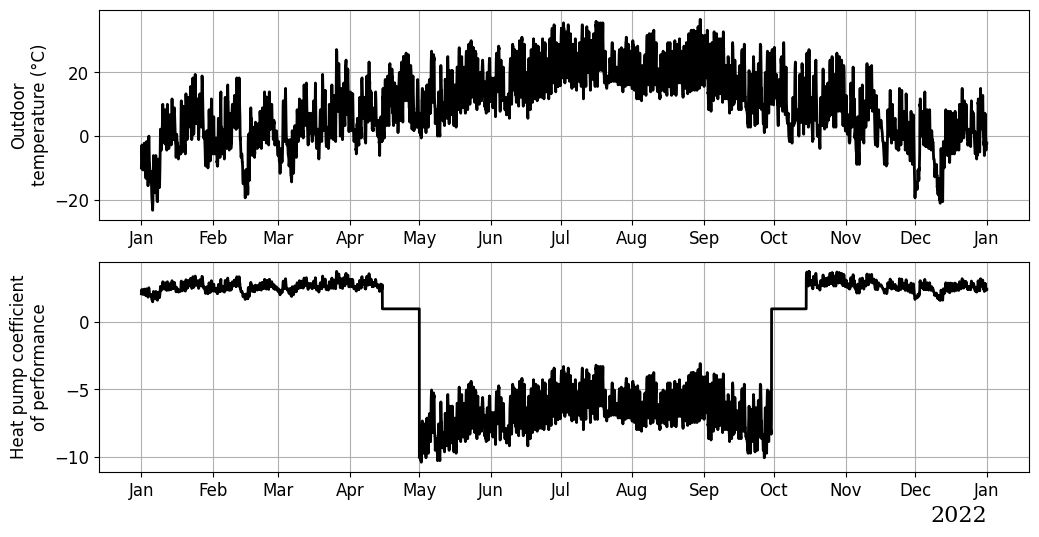

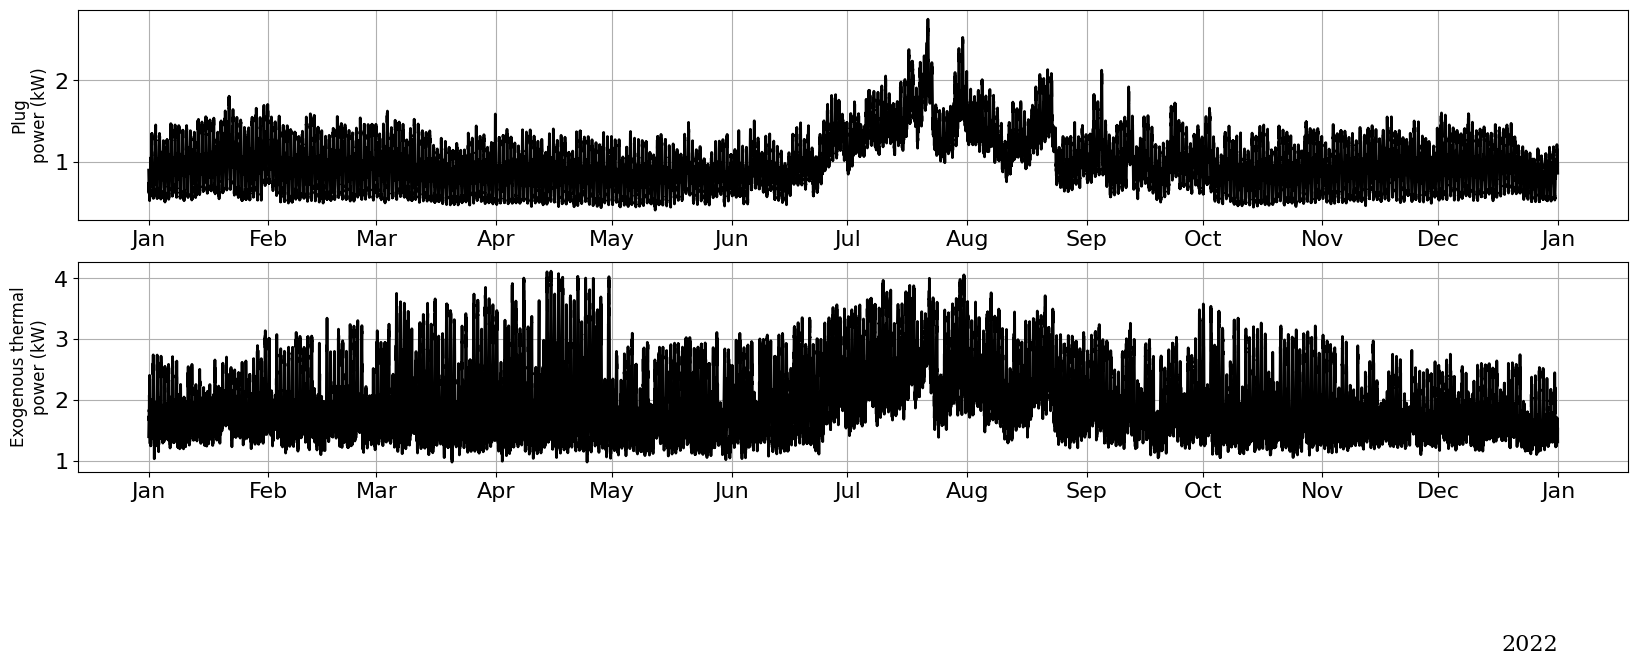

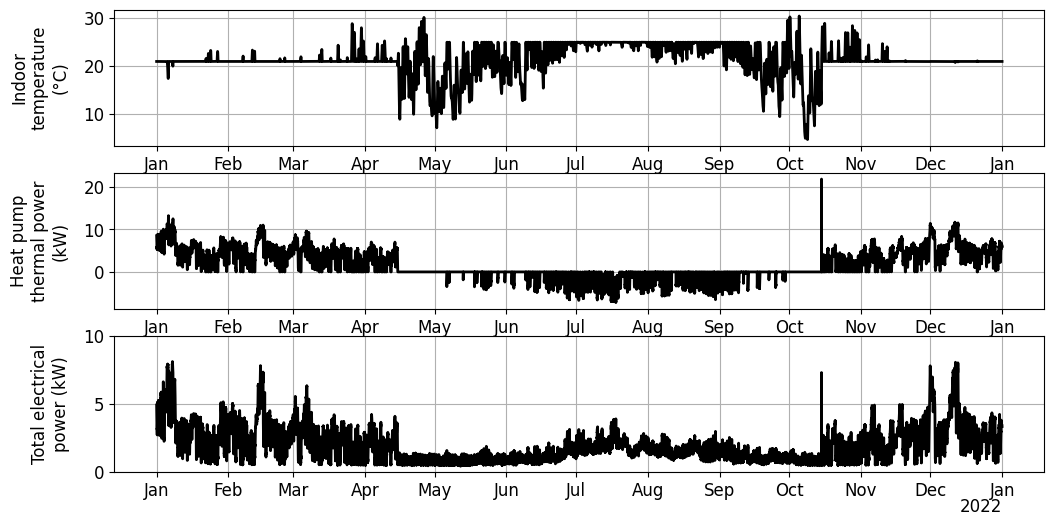

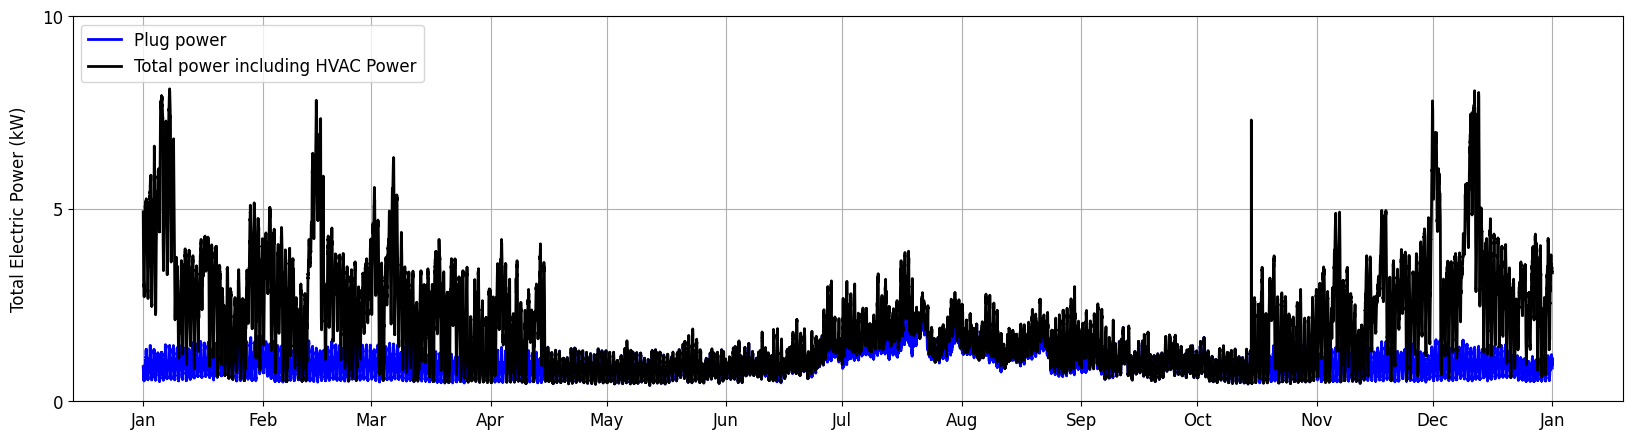

In [81]:
# ==============================================================================
# building electricity demand
# ==============================================================================

electricity_file = 'MFRED-2019-NYC-Apartments-Electricity-Data.csv'  # electricity file name
Af = 200  # floor area, m^2
N = 2  # number of stories
to_plot = 1  # indicator of whether to plot simulation data and results
p = generate_electricity_demand(t_span, electricity_file, Af, N, theta, total_horizontal, to_plot)  # total electricity demand, kW
plt.show()

The solar angles can be calcuated for a given latitude and logitude and subsequently the surface irradiance on the tilted panel can be calculated.

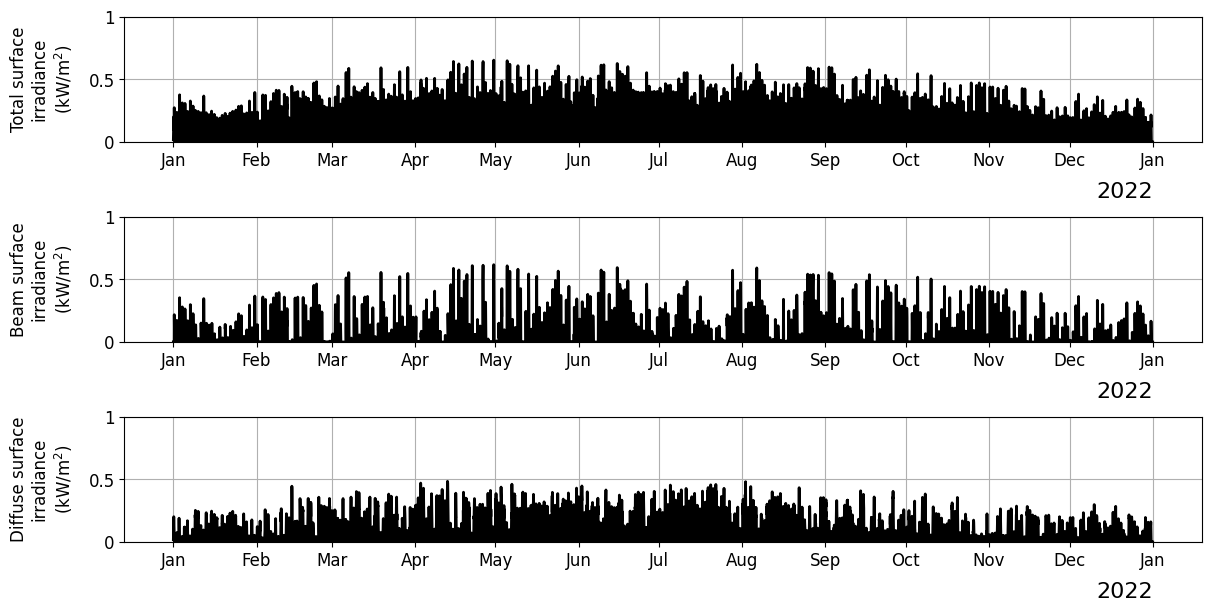

In [82]:
# ==============================================================================
# irradiance
# ==============================================================================
# solar angles
lat = 40.015  # latitude, degrees
t_long = -105.2705  # longitude, degrees
el, az = solar_angles(lat, t_long, t_span, offset_gmt)  # sun elevation and azimuth angles, degrees

# surface irradiance
bet = lat  # surface tilt angle, degrees
az0 = 0  # surface azimuth angle, degrees
Stot, Sb, Sd = surface_irradiance(az, el, az0, bet, beam_normal, diffuse_horizontal)  # total, beam, and diffuse irradiance on surface, kW/m^2

# irradiance plot
p_lim = [0, 1]
t_lim = [t_span[0], t_span[-1]]
plt.figure(5, figsize=(12, 6), constrained_layout=True)
irradiance_data = [(Stot, 'Total surface\nirradiance\n(kW/m$^2$)', p_lim, [0, 0.5, 1]),
                   (Sb, 'Beam surface\nirradiance\n(kW/m$^2$)', p_lim, [0, 0.5, 1]),
                   (Sd, 'Diffuse surface\nirradiance\n(kW/m$^2$)', p_lim, [0, 0.5, 1])]

for i, (y_data, ylabel, ylim, yticks) in enumerate(irradiance_data, start=1):
    ax = plt.subplot(3, 1, i)
    plt.plot(t_span, y_data, 'k', linewidth=2)
    plt.grid(True)
    ax.set_ylabel(ylabel, labelpad=10, loc='center')
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}' if x.is_integer() else f'{x}'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.text(t_span[-1], ylim[0] - 0.4, '2022', fontsize=16, ha='right', va='center')
plt.draw()
plt.show()

### Solar Power Output

Consider a solar panel with a rated efficiency ($\tilde \eta$) of 18% at a rated temperature ($\tilde T$) of $25^\circ C$ and zero output temperature ($T_0$) of $270^\circ C$. The efficiency of the solar panel can be calculated as follows:
$$
\eta \approx \tilde \eta \left( 1 - \frac{T_c - \tilde T}{T_0 - \tilde T} \right)
$$
where the cell temperature ($T_c$) is given by $T_{out} + (35^\circ C m^2/kW)S_{tot}$. Assuming that the panel covers a quarter of the total roof area, the solar power output can be calculated as follows:
$$
P_{sun} = \eta \times \frac{1}{4} A_f S_{tot} \tag{17}
$$

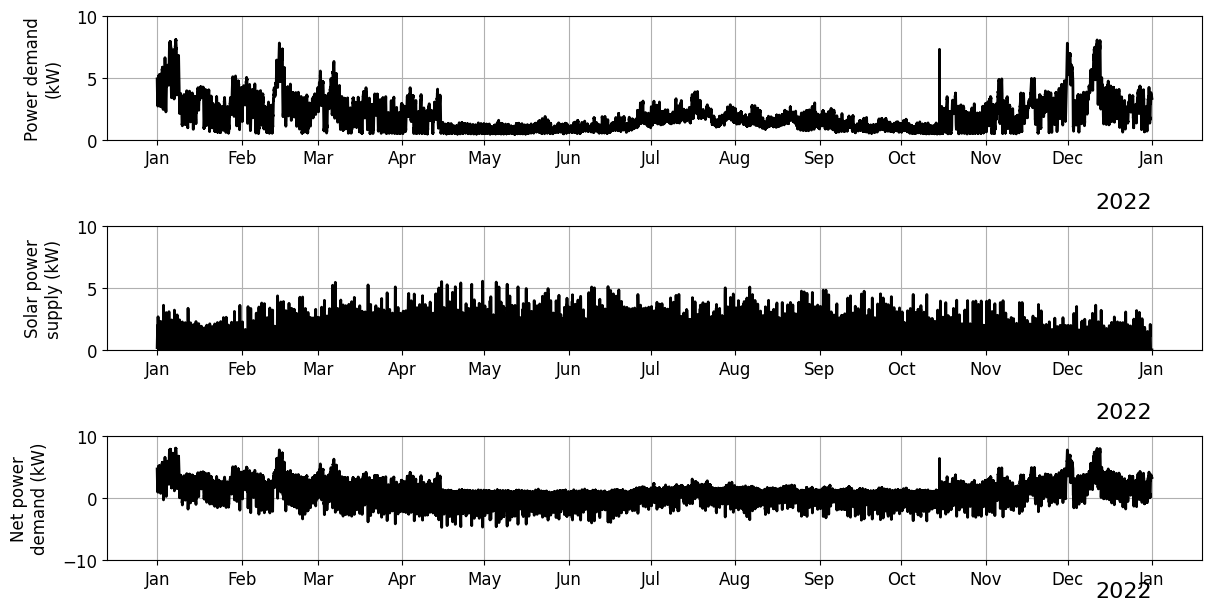

In [83]:
# ==============================================================================
# solar power supply
# ==============================================================================

# solar array efficiency
rated_eta = 0.18  # rated solar array efficiency
rated_t = 25  # rated temperature, C
zero_t = 270  # temperature at which power output stops, C
#solar_eta = np.nan
# ^^^^ YOUR CODE HERE ^^^^
solar_eta = rated_eta * (1 - (theta + 35 * Stot - rated_t) / (zero_t - rated_t))  # solar conversion efficiency

# solar power supply
panel_a = Af / 4  # solar panel area, m^2
p_sun = panel_a * solar_eta * Stot  # solar power supply, kW

# Power plot
plt.figure(6, figsize=(12, 6), constrained_layout=True)
data = [(p, 'Power demand\n(kW)', (0, 10), [0, 5, 10]),
        (p_sun, 'Solar power\nsupply (kW)', (0, 10), [0, 5, 10]),
        (p - p_sun, 'Net power\ndemand (kW)', (-10, 10), [-10, 0, 10])]

for i, (y_data, ylabel, ylim, yticks) in enumerate(data, start=1):
    ax = plt.subplot(3, 1, i)
    plt.plot(t_span, y_data, 'k', linewidth=2)
    plt.grid(True)
    ax.set_ylabel(ylabel, labelpad=10, loc='center')
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.text(t_span[-1], ylim[0] - 5, '2022', fontsize=16, ha='right', va='center')

plt.draw()
plt.show()


### Cost Savings from Solar
Finally, the cost savings from solar can be calculated under one-to-one net metering and net metering with a reduced buyback price. Let us assume that the base retail price of electricity is $C_{elec}^{buy}$. The total electricity consumption cost without any solar generation is,
$$
C_1 = C_{elec}^{buy} \times \sum_{t=1}^{T} P(t) \tag{18}
$$

Under one-to-one net metering, the user pays for the net electricity consumption, which is the total electricity consumption minus the solar generation. Therefore, the cost under one-to-one net metering is given by:
$$
C_2 = C_{elec}^{buy} \times \sum_{t=1}^{T} (P(t) - P_{sun}(t)) \tag{19}
$$

In this case the utility buys the excess solar generation at the same price as the retail price. However, under net metering with a reduced buyback price, the utility buys the excess solar generation at a reduced price, say $C_{elec}^{sell}$. Therefore, the cost under net metering with a reduced buyback price is given by:
$$
C_3 = \sum_{t=1}^{T} \max\left(C_{elec}^{buy}(P(t)-P_{sun}(t)), C_{elec}^{sell}(P(t)-P_{sun}(t))\right) \tag{20}
$$

In [84]:
# ==============================================================================
# electricity costs
# ==============================================================================

# cost without solar
pi_buy = 0.15  # price at which user buys electricity, $/kWh
c1 = round(pi_buy * dt * np.sum(p))  # electricity cost, $

print('--------------------------------------------------------------')
print(f'Electricity cost without solar: ${c1}.')

# cost with one-to-one net metering
c2 = round(pi_buy * dt * np.sum(p - p_sun))  # electricity cost, $
print(f'Electricity cost with solar and one-to-one net metering: ${c2}.')
print(f'Cost reduction from solar with one-to-one net metering: ${c1 - c2} ({round(100 * (1 - c2 / c1))}%).')

# cost with reduced net metering
pi_sell = 0.03  # reduced price at which user sells electricity, $/kWh
c3 = round(dt * np.sum(np.maximum(pi_buy * (p - p_sun), pi_sell * (p - p_sun))))  # electricity cost, $
#c3 = np.nan
# ^^^^ YOUR CODE HERE ^^^^

print(f'Electricity cost with solar and reduced net metering: ${c3}.')
print(f'Cost reduction from solar with reduced net metering: ${c1 - c3} ({round(100 * (1 - c3 / c1))}%).')

# plt.ioff()

plt.show()

--------------------------------------------------------------
Electricity cost without solar: $2579.
Electricity cost with solar and one-to-one net metering: $1534.
Cost reduction from solar with one-to-one net metering: $1045 (41%).
Electricity cost with solar and reduced net metering: $1845.
Cost reduction from solar with reduced net metering: $734 (28%).
